# 04 — Redes Convolucionales 1D (Conv1D)
Input `(N, V_in, 23)`. Conv1D extrae patrones locales en la dimensión temporal.
Catálogo activo: **conv_s** (Conv1D + GlobalAvgPool). Descomentar `[EXTENDER]` para más variantes.

> Nota: Conv1D requiere V_in ≥ kernel_size (3). Para V_in=5 funciona correctamente.

https://github.com/Romequinco/TAREA_REDES_NEURONALES

In [49]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, yfinance as yf
import tensorflow as tf

warnings.simplefilter('ignore')

from keras import Sequential, Input
from keras.layers import Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS,
                   create_time_series_data, make_splits, eval_mae,
                   get_callbacks, restore_best_weights, compile_model,
                   plot_mae_matrix, build_results_df, best_per_window)

In [50]:
# ── HIPERPARÁMETROS ───────────────────────────────────────────
EPOCHS     = 150
BATCH_SIZE = 64
QUICK_MODE = False
if QUICK_MODE: EPOCHS = 50

precios = yf.download(TICKERS, start='1960-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns = np.log(precios).diff().dropna()
print(f'Retornos: {returns.shape}  |  EPOCHS={EPOCHS}')

Retornos: (16195, 23)  |  EPOCHS=150


## Individualizando

Existen **16 posibles combinaciones** de tamaños de ventanas de entrada-salida. Estas combinaciones se obtienen al cruzar las ventanas de entrada (`V_in`) con las ventanas de salida (`V_out`).

Las combinaciones consideradas son:

| Nº | `V_in` días | `V_out` días |
|---:|------------:|-------------:|
| 1  | 5  | 1  |
| 2  | 5  | 5  |
| 3  | 5  | 30 |
| 4  | 5  | 90 |
| 5  | 10 | 1  |
| 6  | 10 | 5  |
| 7  | 10 | 30 |
| 8  | 10 | 90 |
| 9  | 30 | 1  |
| 10 | 30 | 5  |
| 11 | 30 | 30 |
| 12 | 30 | 90 |
| 13 | 90 | 1  |
| 14 | 90 | 5  |
| 15 | 90 | 30 |
| 16 | 90 | 90 |

Se entrenará **un modelo para cada combinación de ventanas**, con el objetivo de comparar su rendimiento y determinar cuál de ellas ofrece la mejor opción.

# Modelo 1

In [51]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_1 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.25

model_1.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_1 = model_1.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_1)

# Evaluación
result = {
    'train': eval_mae(model_1, X_tr, y_tr),
    'val':   eval_mae(model_1, X_v, y_v),
    'test':  eval_mae(model_1, X_ts, y_ts),
    'params': model_1.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_1.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in= 5 out= 1 | train=0.0118 val=0.0111 test=0.0185 ep=150


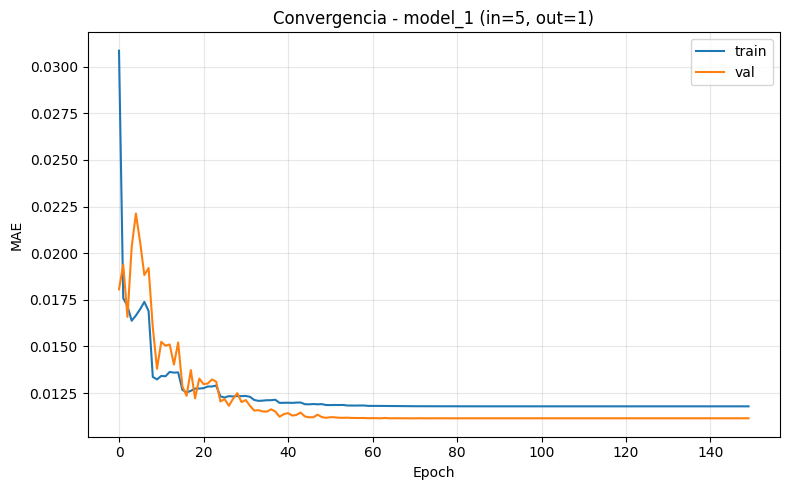

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(hist_1.history['loss'], label='train')
plt.plot(hist_1.history['val_loss'], label='val')

plt.title(f'Convergencia - model_1 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


modelo  V_in  V_out    train      val     test  params  ep
conv_s     5      1 0.011793 0.011142 0.018478    5975 150


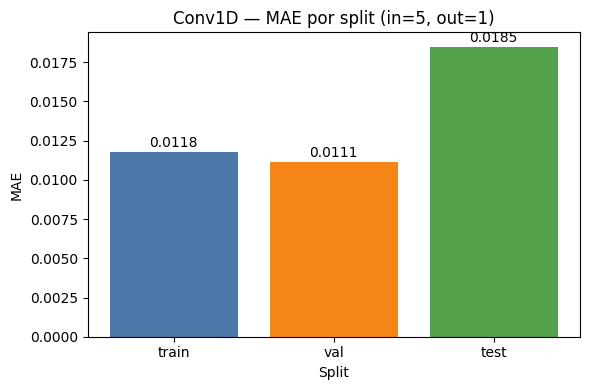

In [53]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_1.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 2

In [54]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 5    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_2 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.2

model_2.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_2 = model_2.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_2)

# Evaluación
result = {
    'train': eval_mae(model_2, X_tr, y_tr),
    'val':   eval_mae(model_2, X_v, y_v),
    'test':  eval_mae(model_2, X_ts, y_ts),
    'params': model_2.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_2.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in= 5 out= 5 | train=0.0055 val=0.0064 test=0.0084 ep=150


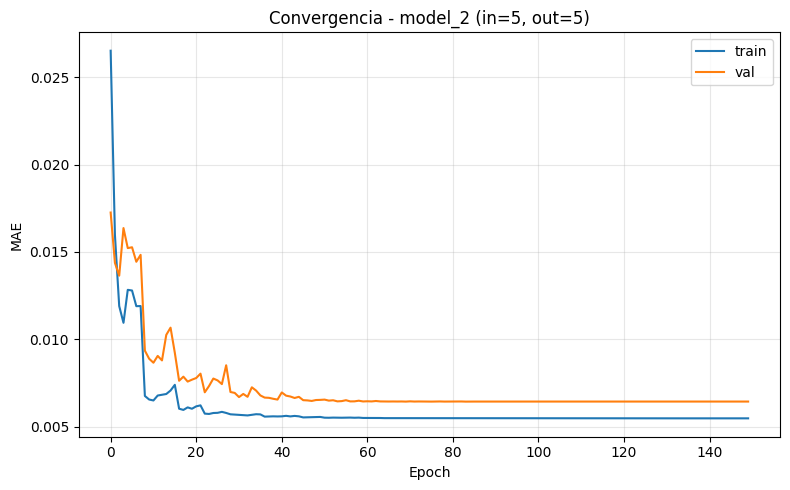

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(hist_2.history['loss'], label='train')
plt.plot(hist_2.history['val_loss'], label='val')

plt.title(f'Convergencia - model_2 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s     5      5 0.005489 0.006442 0.008408    5975 150


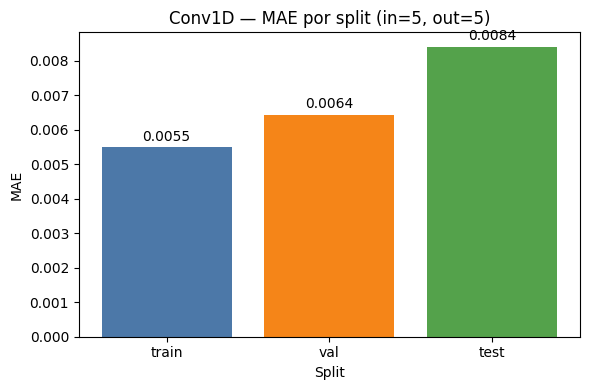

In [56]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_2.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 3

In [57]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 30    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_3 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.2

model_3.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_3 = model_3.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_3)

# Evaluación
result = {
    'train': eval_mae(model_3, X_tr, y_tr),
    'val':   eval_mae(model_3, X_v, y_v),
    'test':  eval_mae(model_3, X_ts, y_ts),
    'params': model_3.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_3.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in= 5 out=30 | train=0.0022 val=0.0036 test=0.0077 ep=150


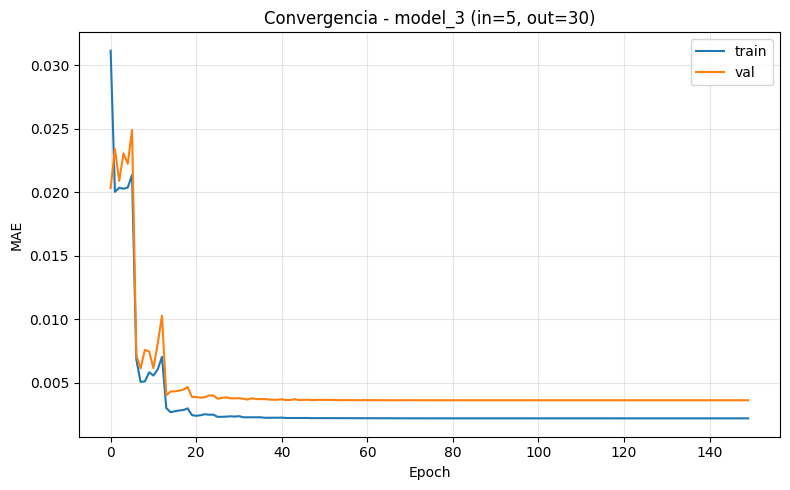

In [58]:
plt.figure(figsize=(8, 5))
plt.plot(hist_3.history['loss'], label='train')
plt.plot(hist_3.history['val_loss'], label='val')

plt.title(f'Convergencia - model_3 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s     5     30 0.002204 0.003629 0.007739    5975 150


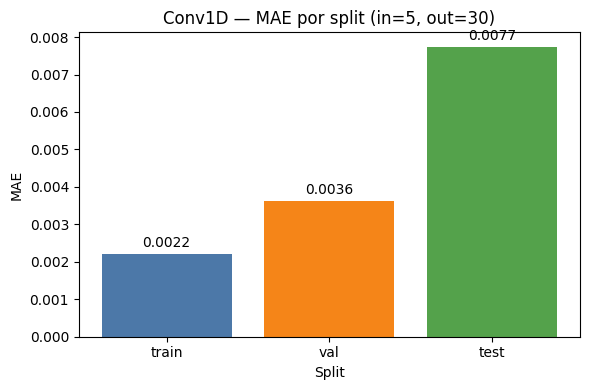

In [59]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_3.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 4

In [60]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 5  # cambia esto por la ventana de entrada que quieras
V_out = 90    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_4 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.2

model_4.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_4 = model_4.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_4)

# Evaluación
result = {
    'train': eval_mae(model_4, X_tr, y_tr),
    'val':   eval_mae(model_4, X_v, y_v),
    'test':  eval_mae(model_4, X_ts, y_ts),
    'params': model_4.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_4.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in= 5 out=90 | train=0.0013 val=0.0035 test=0.0111 ep=150


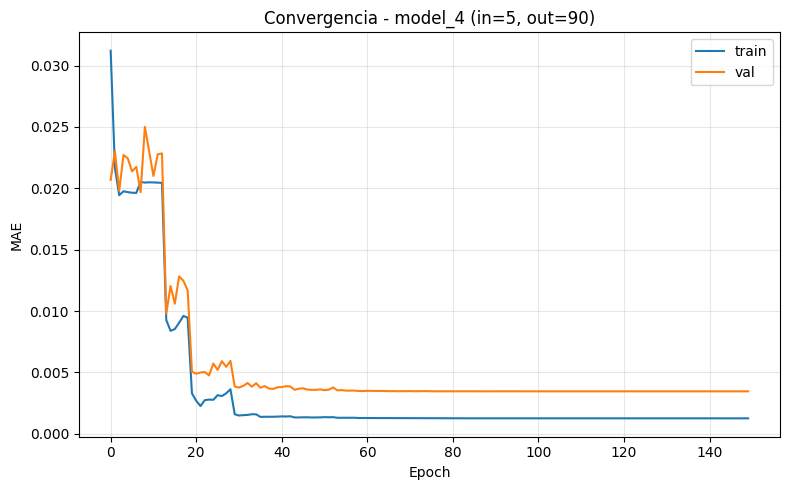

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(hist_4.history['loss'], label='train')
plt.plot(hist_4.history['val_loss'], label='val')

plt.title(f'Convergencia - model_4 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train     val    test  params  ep
conv_s     5     90 0.001261 0.00346 0.01108    5975 150


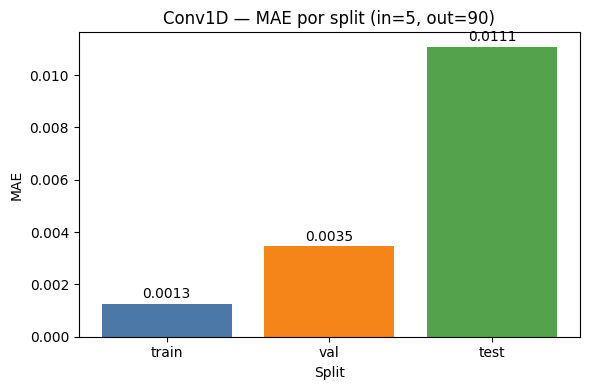

In [62]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_4.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 5

In [63]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_5 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_5.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_5 = model_5.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_5)

# Evaluación
result = {
    'train': eval_mae(model_5, X_tr, y_tr),
    'val':   eval_mae(model_5, X_v, y_v),
    'test':  eval_mae(model_5, X_ts, y_ts),
    'params': model_5.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_5.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out= 1 | train=0.0118 val=0.0130 test=0.0226 ep=150


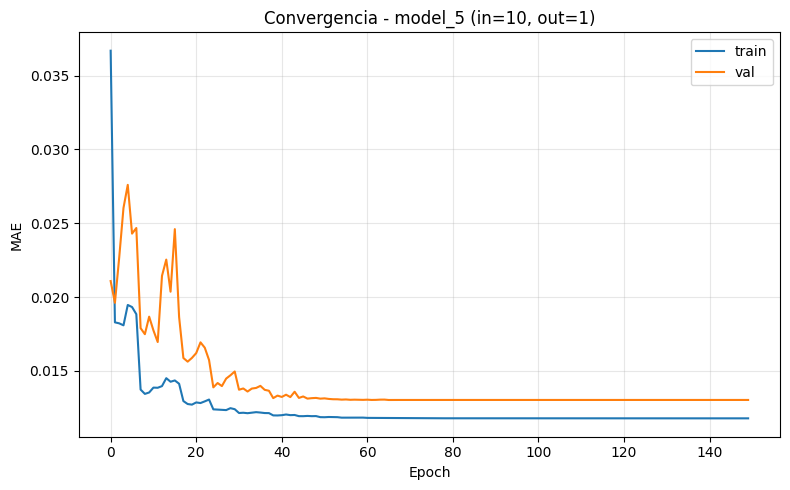

In [64]:
plt.figure(figsize=(8, 5))
plt.plot(hist_5.history['loss'], label='train')
plt.plot(hist_5.history['val_loss'], label='val')

plt.title(f'Convergencia - model_5 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val    test  params  ep
conv_s    10      1 0.011804 0.013027 0.02259    5975 150


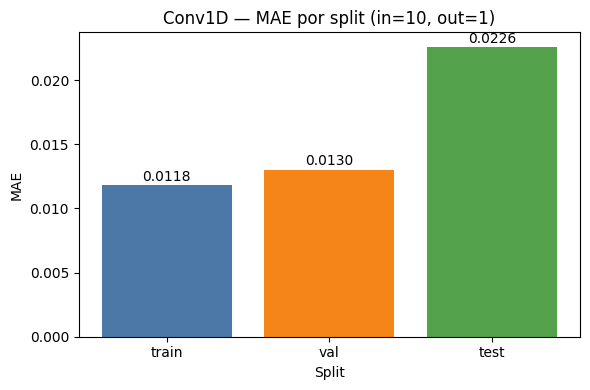

In [65]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_5.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 6

In [66]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 5    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_6 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_6.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_6 = model_6.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_6)

# Evaluación
result = {
    'train': eval_mae(model_6, X_tr, y_tr),
    'val':   eval_mae(model_6, X_v, y_v),
    'test':  eval_mae(model_6, X_ts, y_ts),
    'params': model_6.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_6.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out= 5 | train=0.0055 val=0.0067 test=0.0152 ep=150


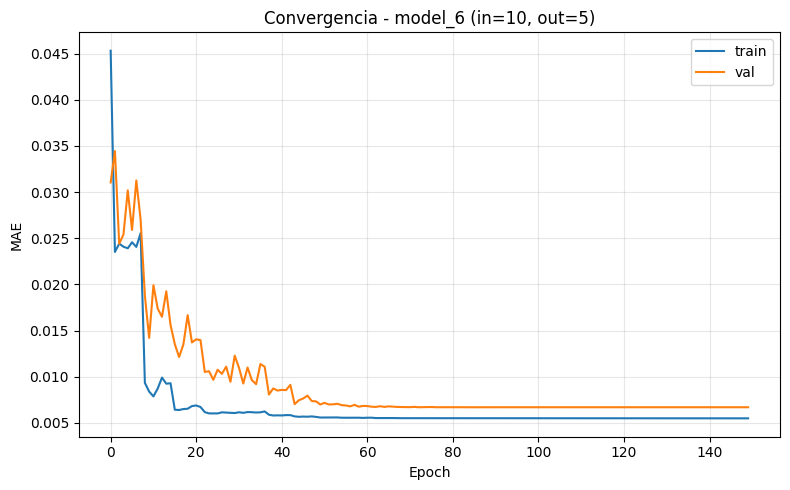

In [67]:
plt.figure(figsize=(8, 5))
plt.plot(hist_6.history['loss'], label='train')
plt.plot(hist_6.history['val_loss'], label='val')

plt.title(f'Convergencia - model_6 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s    10      5 0.005491 0.006683 0.015168    5975 150


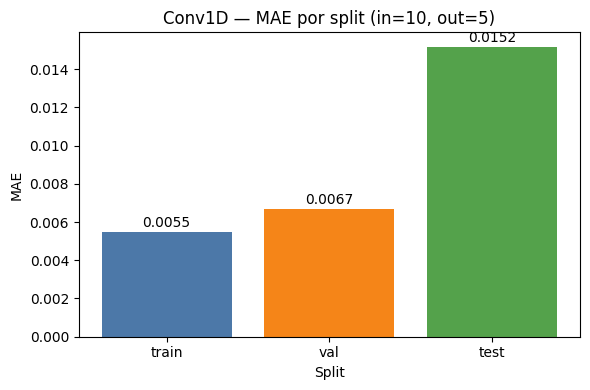

In [68]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_6.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 7

In [69]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 30    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_7 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_7.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_7 = model_7.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_7)

# Evaluación
result = {
    'train': eval_mae(model_7, X_tr, y_tr),
    'val':   eval_mae(model_7, X_v, y_v),
    'test':  eval_mae(model_7, X_ts, y_ts),
    'params': model_7.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_7.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out=30 | train=0.0022 val=0.0040 test=0.0064 ep=150


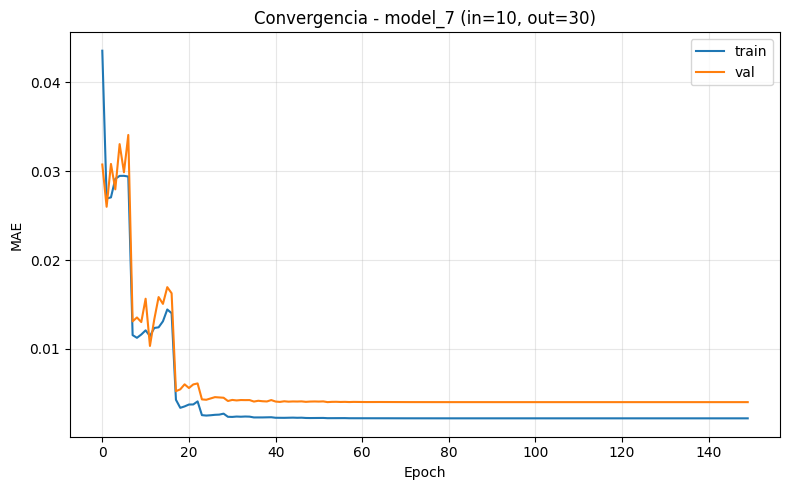

In [70]:
plt.figure(figsize=(8, 5))
plt.plot(hist_7.history['loss'], label='train')
plt.plot(hist_7.history['val_loss'], label='val')

plt.title(f'Convergencia - model_7 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val    test  params  ep
conv_s    10     30 0.002205 0.004023 0.00637    5975 150


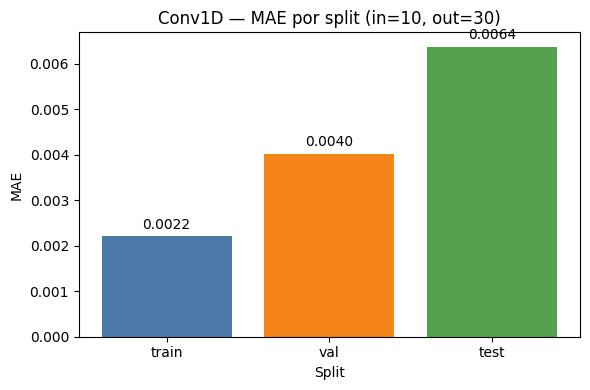

In [71]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_7.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 8

In [72]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 10  # cambia esto por la ventana de entrada que quieras
V_out = 90    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_8 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_8.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_8 = model_8.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_8)

# Evaluación
result = {
    'train': eval_mae(model_8, X_tr, y_tr),
    'val':   eval_mae(model_8, X_v, y_v),
    'test':  eval_mae(model_8, X_ts, y_ts),
    'params': model_8.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_8.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=10 out=90 | train=0.0013 val=0.0032 test=0.0045 ep=150


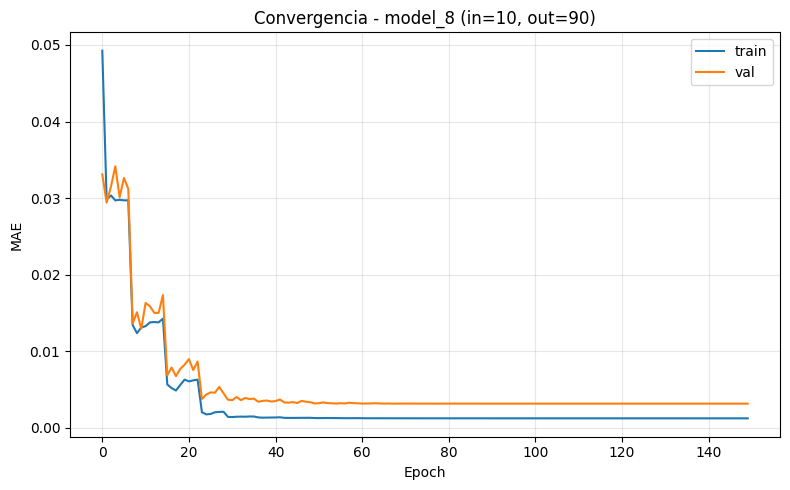

In [73]:
plt.figure(figsize=(8, 5))
plt.plot(hist_8.history['loss'], label='train')
plt.plot(hist_8.history['val_loss'], label='val')

plt.title(f'Convergencia - model_8 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out    train      val     test  params  ep
conv_s    10     90 0.001263 0.003177 0.004465    5975 150


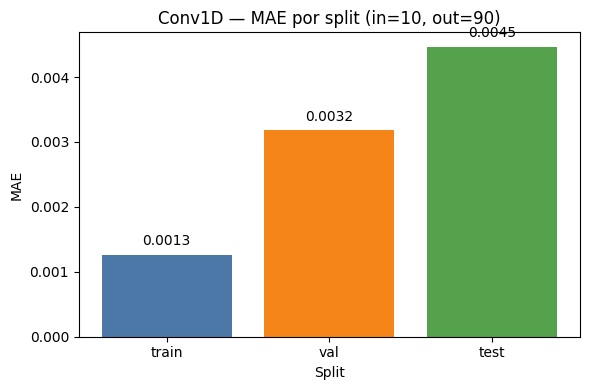

In [74]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_8.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Modelo 9

In [75]:
tf.keras.backend.clear_session()

# Elegir UNA configuración concreta
V_in  = 30  # cambia esto por la ventana de entrada que quieras
V_out = 1    # cambia esto por la ventana de salida que quieras
L2_REG = 0.000

model_9 = Sequential([
    Input((V_in, 23)),
    Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(L2_REG)),
    GlobalAveragePooling1D(),
    Dense(23)
])

LEARNING_RATE = 0.3

model_9.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='mae',
    metrics=['mae']
)

X, y = create_time_series_data(returns, V_in, V_out)
X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

# Entrenar solo este modelo
hist_9 = model_9.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=0
)

print('Entrenamiento terminado.')

restore_best_weights(model_9)

# Evaluación
result = {
    'train': eval_mae(model_9, X_tr, y_tr),
    'val':   eval_mae(model_9, X_v, y_v),
    'test':  eval_mae(model_9, X_ts, y_ts),
    'params': model_9.count_params()
}

print(
    f'conv_s | in={V_in:2d} out={V_out:2d} | '
    f'train={result["train"]:.4f} '
    f'val={result["val"]:.4f} '
    f'test={result["test"]:.4f} '
    f'ep={len(hist_9.history["loss"])}'
)

Entrenamiento terminado.
conv_s | in=30 out= 1 | train=0.0118 val=0.0116 test=0.0170 ep=150


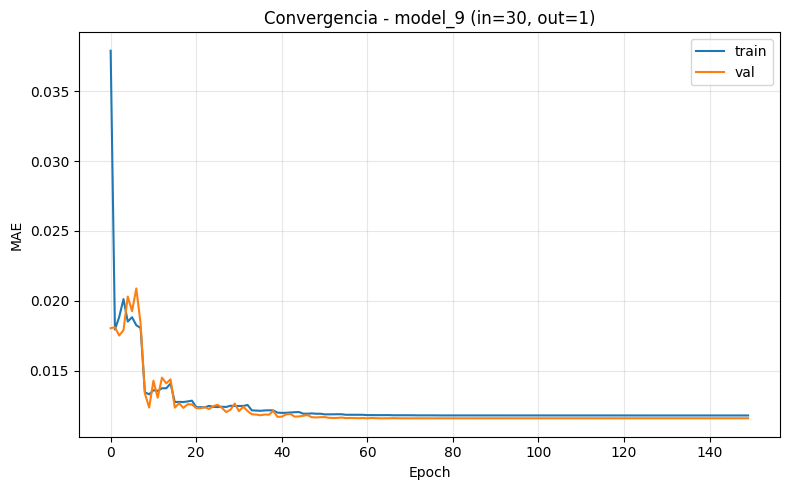

In [76]:
plt.figure(figsize=(8, 5))
plt.plot(hist_9.history['loss'], label='train')
plt.plot(hist_9.history['val_loss'], label='val')

plt.title(f'Convergencia - model_9 (in={V_in}, out={V_out})')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

modelo  V_in  V_out  train      val     test  params  ep
conv_s    30      1 0.0118 0.011584 0.017042    5975 150


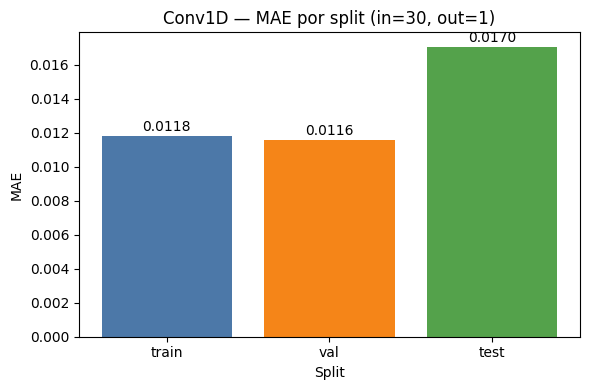

In [77]:
# Tabla resumen del modelo
df_res = pd.DataFrame([{
    'modelo': 'conv_s',
    'V_in': V_in,
    'V_out': V_out,
    'train': result['train'],
    'val': result['val'],
    'test': result['test'],
    'params': result['params'],
    'ep': len(hist_9.history['loss'])
}])

print(df_res.to_string(index=False))

# Gráfico comparando train / val / test
labels = ['train', 'val', 'test']
values = [result['train'], result['val'], result['test']]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=['#4C78A8', '#F58518', '#54A24B'])

plt.title(f'Conv1D — MAE por split (in={V_in}, out={V_out})')
plt.xlabel('Split')
plt.ylabel('MAE')

for bar, v in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0001,
        f'{v:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()
